# TASK 05 — Regression Modeling From Scratch to Production

## Project Overview

This project focuses on developing a complete regression modeling workflow for a PropTech startup that requires reliable house price predictions.

The California Housing dataset provided by scikit-learn is used to develop, evaluate, compare, and diagnose multiple regression models. The workflow covers data understanding, preprocessing, baseline modeling, regularized regression, polynomial regression, cross-validation, residual analysis, prediction intervals, and final model selection.

## Business Scenario

A PropTech startup is developing a house price estimation application that serves approximately 10,000 predictions per day.

Predictions within ±$30,000 of the actual house value are considered acceptable. Predictions outside this range may reduce user trust and cause users to leave the application.

The goal is therefore to develop a regression model that provides accurate predictions while maintaining a reproducible, modular, and production-ready workflow.

## Dataset

- **Dataset:** California Housing
- **Source:** Scikit-learn built-in dataset
- **Problem Type:** Supervised Learning — Regression
- **Observations:** 20,640
- **Predictor Variables:** 8
- **Target Variable:** `MedHouseVal`

The target variable represents median house value and is expressed in units of $100,000.

## Business Success Criterion

The acceptable prediction error is ±$30,000.

Since the target is measured in units of $100,000:

**$30,000 = 0.30 target units**

This criterion will be considered when evaluating the final model.

## Learning Objectives

- Understand regression modeling principles.
- Prepare and preprocess the dataset.
- Establish a baseline model.
- Train and compare multiple regression models.
- Apply Ridge, Lasso, and ElasticNet regularization.
- Implement polynomial regression.
- Perform cross-validation.
- Analyze residuals and regression assumptions.
- Estimate prediction intervals.
- Select the most suitable model based on model performance and business requirements.
- Develop a modular and reproducible solution.

# STEP 1 — Data Understanding and Exploratory Analysis

This step focuses on understanding the California Housing dataset before applying any preprocessing or regression model.

The dataset structure, data quality, statistical characteristics, target variable, and feature relationships will be examined to determine the appropriate modeling strategy.

### Step 1.1 — Import Required Libraries

The required Python libraries are imported for data loading, manipulation, numerical analysis, and visualization.

Only libraries required for the current analysis are imported at this stage. Modeling-specific libraries will be introduced when the corresponding models are developed.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing

import warnings
warnings.filterwarnings("ignore")

### Step 1.2 — Load the California Housing Dataset

The California Housing dataset is loaded directly from scikit-learn's built-in datasets.

Using the built-in dataset ensures that the required dataset is loaded consistently without relying on an external or modified dataset file.

In [3]:
housing = fetch_california_housing(as_frame=True)

df = housing.frame.copy()

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Step 1.3 — Examine Dataset Dimensions

The dimensions of the dataset are examined to determine the total number of observations and variables available for analysis.

This helps us understand the size of the dataset before performing preprocessing and model training.

In [4]:
df.shape

(20640, 9)

### Observation

The California Housing dataset contains **20,640 observations and 9 variables**. Among these variables, **8 are predictor features** used for house value estimation, while **1 variable is the target** that the regression models will predict.

The dataset provides a sufficiently large number of observations for training and evaluating regression models.

### Step 1.4 — Identify Features and Target Variable

The dataset columns are examined to identify the predictor variables and the target variable.

The predictor variables contain information that can be used by the regression models, while the target variable represents the house value that the models are required to predict.

In [5]:
print("Columns:")
print(df.columns.tolist())

Columns:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


In [6]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

print("Number of features:", X.shape[1])
print("Feature names:", X.columns.tolist())
print("Target variable:", y.name)

Number of features: 8
Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target variable: MedHouseVal


### Observation

The dataset contains **8 predictor variables** and one continuous target variable, `MedHouseVal`.

The predictor variables describe factors such as median income, housing age, number of rooms, population, occupancy, and geographical location. `MedHouseVal` is selected as the target because the business problem requires predicting median house values.

### Step 1.5 — Inspect Data Types and Structure

The data types and overall structure of the dataset are examined to determine whether any variables require type conversion or categorical encoding before modeling.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


### Step 1.6 — Check Missing Values

Missing values can affect regression model training and may require imputation or removal.

Therefore, the dataset is checked for missing values before proceeding to preprocessing.

In [8]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


### Step 1.7 — Check Duplicate Records

Duplicate records may cause repeated observations and can affect the reliability of model evaluation.

The dataset is therefore checked for duplicate rows before model development.

In [9]:
df.duplicated().sum()

np.int64(0)

### Step 1.8 — Generate Statistical Summary

Descriptive statistics are generated to understand the central tendency, variability, and range of the numerical variables.

The summary helps identify differences in feature scales and potential extreme values that may need consideration during preprocessing and model development.

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


### Observation

The statistical summary shows that the dataset contains 20,640 observations for each variable.

The predictor variables have different ranges and scales. For example, `Population` has a mean of approximately 1,425 but a maximum of 35,682, while `AveOccup` has a mean of approximately 3.07 and a maximum of 1,243.33. `AveRooms` also shows a large difference between its median (5.23) and maximum (141.91), indicating the presence of potentially extreme observations.

The target variable, `MedHouseVal`, has a mean of approximately 2.07 and a maximum of 5.00001, where the target is measured in $100,000 units.

These differences in feature scales and the presence of extreme values will be considered during preprocessing and later model diagnostics.

### Step 1.9 — Analyze Target Variable Distribution

The target variable is analyzed separately to understand its numerical range and distribution.

Understanding the target distribution is important because extreme values or strong skewness can influence regression model performance and error behavior.

In [11]:
y.describe()

,MedHouseVal
count,20640.000000
mean,2.068558
std,1.153956
min,0.149990
25%,1.196000
50%,1.797000
75%,2.647250
max,5.000010


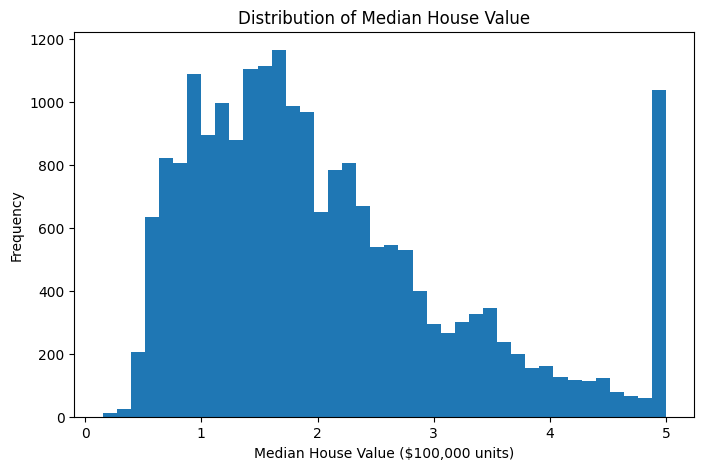

In [12]:
plt.figure(figsize=(8, 5))

plt.hist(y, bins=40)

plt.xlabel("Median House Value ($100,000 units)")
plt.ylabel("Frequency")
plt.title("Distribution of Median House Value")

plt.show()

### Observation

The target variable `MedHouseVal` shows a non-symmetric distribution with most observations concentrated approximately between **0.7 and 2.5** ($70,000–$250,000).

The distribution gradually extends toward higher house values, indicating a **right-skewed pattern**. A noticeable concentration is also present near the upper limit of approximately **5.0** ($500,000).

This distribution indicates that higher-value properties are less frequent than the observations in the central range. The target distribution will therefore be considered during model evaluation and residual analysis.

### Step 1.10 — Analyze Feature-Target Relationships

Correlation analysis is performed to examine the strength and direction of the linear relationship between each predictor and the target variable.

This provides an initial understanding of which features may have stronger relationships with house values and can help guide the later modeling analysis.

Correlation indicates statistical association and does not establish causation.

In [13]:
correlation = df.corr(numeric_only=True)["MedHouseVal"].sort_values(
    ascending=False
)

correlation

,MedHouseVal
MedHouseVal,1.000000
MedInc,0.688075
AveRooms,0.151948
HouseAge,0.105623
AveOccup,-0.023737
Population,-0.024650
Longitude,-0.045967
AveBedrms,-0.046701
Latitude,-0.144160


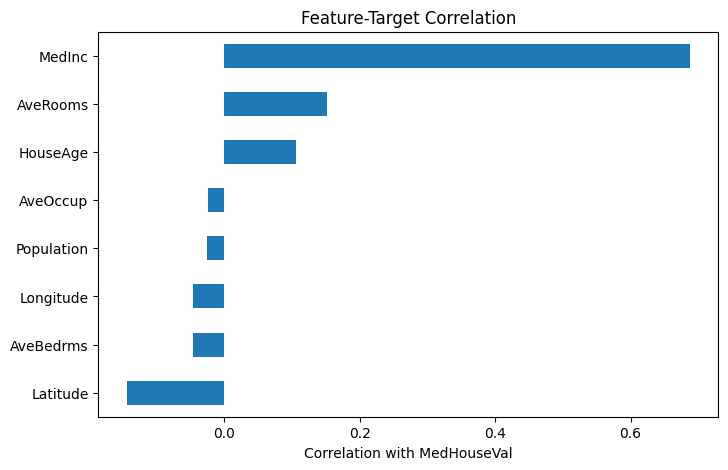

In [14]:
plt.figure(figsize=(8, 5))

correlation.drop("MedHouseVal").sort_values().plot(kind="barh")

plt.xlabel("Correlation with MedHouseVal")
plt.title("Feature-Target Correlation")

plt.show()

### Observation

The feature-target correlation analysis shows that `MedInc` (Median Income) has the strongest positive linear relationship with `MedHouseVal`, with a correlation of approximately **0.69**. This indicates that districts with higher median income generally tend to have higher median house values.

`AveRooms` (Average Rooms) and `HouseAge` (Median House Age) show weaker positive relationships with the target, while `Latitude` shows a weak negative relationship.

`AveBedrms` (Average Bedrooms), `Longitude`, `Population`, and `AveOccup` (Average Occupancy) show relatively weak linear correlations with `MedHouseVal`.

Although some features have weak individual correlations, they will not be removed solely on the basis of correlation because multiple regression models can use combined information from several predictors.

Overall, `MedInc` appears to be an important predictor and will be retained along with the other features for further modeling.

### Step 1.11 — Initial Data Analysis Summary

The initial analysis provided a clear understanding of the California Housing dataset before model development.

The dataset contains **20,640 observations and 8 predictor variables**, with `MedHouseVal` as the continuous target variable. No missing values or duplicate records were identified.

The statistical summary showed that the predictors have different scales and that some variables, particularly `AveRooms`, `Population`, and `AveOccup`, contain potentially extreme values. The target distribution is non-symmetric, with most observations concentrated in the lower-to-middle value range and a noticeable concentration near the upper limit.

The correlation analysis showed that `MedInc` has the strongest positive linear relationship with `MedHouseVal`, while several other features have weaker individual relationships.

These findings will guide the preprocessing and modeling decisions in the next stage. The identified differences in feature scales will be addressed through an appropriate preprocessing pipeline, while potential extreme observations will be considered during later model diagnostics.

# STEP 2 — Data Cleaning and Preprocessing

After understanding the dataset, the next step is to prepare the data for regression modeling.

The initial analysis showed that the dataset contains no missing values or duplicate records, so no imputation or duplicate removal is required.

The main preprocessing requirements are to separate the features from the target, split the data into training and testing sets, and apply feature scaling through a pipeline.

A pipeline will be used to prevent data leakage by learning preprocessing parameters only from the training data.

### Step 2.1 — Review Data Quality Decisions

The results from the initial data-quality checks are reviewed before preprocessing.

No missing values or duplicate records were found. Therefore, the dataset does not require missing-value imputation or duplicate removal.

The predictor variables are numerical, so categorical encoding is also not required.

The main preprocessing requirement is feature scaling because the predictor variables have considerably different numerical ranges.

In [15]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Number of features:", X.shape[1])

Missing values: 0
Duplicate rows: 0
Number of features: 8


### Step 2.2 — Separate Features and Target

The predictor variables are separated from the target variable before splitting the dataset.

`X` contains the information used by the model to make predictions, while `y` contains the actual median house values that the model will learn to predict.

In [16]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (20640, 8)
Target shape: (20640,)


### Observation

The dataset was successfully separated into **8 predictor variables (`X`)** and **1 continuous target variable (`y`)**.

The feature matrix contains 20,640 observations and 8 input variables, while the target contains 20,640 corresponding house-value observations.

### Step 2.3 — Split Data into Training and Testing Sets

The dataset is divided into training and testing subsets before applying model preprocessing.

The training set will be used to learn model parameters, while the testing set will remain unseen during training and will be used for final performance evaluation.

An 80/20 split is used, with 80% of the observations for training and 20% for testing.

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (16512, 8)
Testing features: (4128, 8)
Training target: (16512,)
Testing target: (4128,)


### Observation

The dataset was divided into **80% training data and 20% testing data**.

The training set contains **16,512 observations**, while the testing set contains **4,128 observations**. The testing data will remain unseen during model training and will be used for unbiased evaluation of the final models.

The `random_state=42` setting ensures that the same train-test split can be reproduced.

### Step 2.4 — Examine Feature Scaling Requirements

The predictor variables have different numerical ranges, as observed during the statistical analysis.

For example, `Population` contains values ranging from 3 to 35,682, while `HouseAge` ranges from 1 to 52. Features with larger numerical scales can have a disproportionate influence on models that are sensitive to feature magnitude.

Therefore, standardization will be applied before training the regression models.

In [18]:
X_train.describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
MedInc,3.880754,1.904294,0.499900,15.000100
HouseAge,28.608285,12.602499,1.000000,52.000000
AveRooms,5.435235,2.387375,0.888889,141.909091
AveBedrms,1.096685,0.433215,0.333333,25.636364
Population,1426.453004,1137.056380,3.000000,35682.000000
AveOccup,3.096961,11.578744,0.692308,1243.333333
Latitude,35.643149,2.136665,32.550000,41.950000
Longitude,-119.582290,2.005654,-124.350000,-114.310000


### Observation

The predictor variables have substantially different numerical scales. For example, `Population` contains much larger numerical values than variables such as `HouseAge`, `Latitude`, and `Longitude`.

To place the predictors on a comparable scale and support stable regression modeling, standardization will be applied using `StandardScaler`.

### Step 2.5 — Standardize Numerical Features

Standardization transforms each numerical feature so that it has approximately a mean of 0 and a standard deviation of 1.

This is particularly useful for regression techniques such as Ridge, Lasso, and ElasticNet because these models use regularization, which is affected by feature scale.

The scaler will be fitted only on the training data and then applied to both training and testing data.

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Step 2.6 — Verify Feature Scaling

The standardized training data is checked to confirm that the features have been transformed to a comparable scale.

The mean of each standardized feature should be approximately 0 and the standard deviation should be approximately 1.

In [20]:
print("Training means:")
print(X_train_scaled.mean(axis=0))

print("\nTraining standard deviations:")
print(X_train_scaled.std(axis=0))

Training means:
[-6.51933288e-17 -9.25185854e-18 -1.98108110e-16 -1.70729064e-16
 -2.15159501e-19  4.93656580e-17  6.40099515e-17  1.75333477e-15]

Training standard deviations:
[1. 1. 1. 1. 1. 1. 1. 1.]


### Observation

The verification results confirm that feature standardization was successful.

The means of all 8 training features are approximately **0**, with very small values close to zero resulting from floating-point numerical precision. The standard deviation of every standardized feature is **1**.

Therefore, the training features have been successfully transformed to a common standardized scale and are ready for regression modeling.

### Step 2.7 — Build a Preprocessing Pipeline

A preprocessing pipeline is created to combine feature scaling with model training in a single reproducible workflow.

Using a pipeline ensures that preprocessing is consistently applied during training, validation, and prediction while reducing the risk of data leakage.

The pipeline will be used for the regression models developed in the following steps.

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

linear_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

### Step 2.8 — Verify Data Leakage Prevention

Data leakage is avoided by splitting the dataset before preprocessing and ensuring that preprocessing parameters are learned only from the training data.

The testing data is not used to calculate the scaling parameters during training.

The pipeline will further ensure that this process is handled consistently during model training and evaluation.

### Observation

The preprocessing workflow follows a leakage-free approach. The dataset was split into training and testing sets before scaling, and the scaler was fitted only on the training data.

The testing data was transformed using the parameters learned from the training data. This ensures that information from the unseen testing set does not influence model training.

### Step 2.9 — Preprocessing Summary

The dataset was prepared for regression modeling through a structured preprocessing workflow.

No missing-value treatment or duplicate removal was required. The data was divided into training and testing sets using an 80/20 split. Due to the different numerical scales of the predictor variables, standardization was selected as the appropriate scaling technique.

A pipeline was also established to combine preprocessing and model training while reducing the risk of data leakage.

The processed data is now ready for baseline and regression model development.

# STEP 3 — Baseline Regression Model

Before developing more advanced regression models, a simple baseline is established as a reference point.

The baseline provides a minimum performance benchmark against which the machine learning regression models can be compared.

For this project, the baseline will predict the mean house value from the training data for every observation in the test set.

### Step 3.1 — Calculate Baseline Prediction

The baseline prediction is calculated using the mean target value from the training dataset.

The mean is calculated only from the training target values to ensure that information from the unseen test set is not used.

Every test observation will receive this same mean value as its prediction.


In [22]:
baseline_prediction = y_train.mean()

print("Baseline prediction:", baseline_prediction)

Baseline prediction: 2.071946937378876


### Observation

The mean `MedHouseVal` of the training dataset is **2.07195**, which corresponds to approximately **$207,194.69**.

This value is used as the baseline prediction, meaning that the baseline will predict approximately **$207,194.69 for every observation in the test set**.

This simple prediction will provide a reference point for evaluating the performance of the machine learning regression models.

### Step 3.2 — Generate Baseline Predictions

The calculated training-set mean is used as the prediction for every observation in the test set.

Using a constant prediction allows us to establish how well a very simple strategy performs before applying machine learning models.

In [23]:
baseline_predictions = np.full(
    shape=len(y_test),
    fill_value=baseline_prediction
)

print("Number of baseline predictions:", len(baseline_predictions))
print("First 5 predictions:", baseline_predictions[:5])

Number of baseline predictions: 4128
First 5 predictions: [2.07194694 2.07194694 2.07194694 2.07194694 2.07194694]


### Observation

A total of **4,128 baseline predictions** were generated, matching the number of observations in the test set.

All predictions have the same value of approximately **2.07195**, because the baseline uses the mean house value from the training data as the prediction for every test observation.

This confirms that the baseline is a simple constant-prediction benchmark rather than a model that learns relationships between the input features and house values.

### Step 3.3 — Evaluate Baseline Performance

The baseline predictions are evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score.

These metrics provide a quantitative benchmark that will be used to compare the performance of the regression models developed later.

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_predictions
)

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Baseline R²:", baseline_r2)

Baseline MAE: 0.9060685490007149
Baseline RMSE: 1.1448563543099792
Baseline R²: -0.00021908714592466794


### Observation

The baseline model achieved an **MAE of 0.9061**, corresponding to an average prediction error of approximately **$90,606.85**.

The **RMSE was 1.1449**, or approximately **$114,485.64**, which is higher than the MAE and indicates that some predictions have relatively larger errors.

The baseline **R² was approximately 0 (-0.0002)**, which is expected because the baseline does not learn relationships between the predictor variables and the target; it simply predicts the training-set mean for every observation.

The baseline MAE of 0.9061 is substantially higher than the business threshold of **0.30 ($30,000)**. Therefore, the baseline does not satisfy the business requirement and provides a benchmark that the machine learning regression models must improve upon.

### Step 3.4 — Compare Baseline with Business Requirement

The business requires house-price predictions to remain within approximately **±$30,000** of the actual value.

Since `MedHouseVal` is measured in units of **$100,000**, the business error threshold is equivalent to **0.30 target units**.

The baseline MAE will be compared with this threshold to determine whether the simple baseline satisfies the business requirement.

In [25]:
business_threshold = 0.30

print("Business MAE threshold:", business_threshold)
print("Baseline MAE:", baseline_mae)

if baseline_mae <= business_threshold:
    print("Baseline meets the business requirement.")
else:
    print("Baseline does not meet the business requirement.")

Business MAE threshold: 0.3
Baseline MAE: 0.9060685490007149
Baseline does not meet the business requirement.


### Observation

The baseline MAE of **0.9061** is substantially higher than the business threshold of **0.30**.

Therefore, the baseline model does **not** satisfy the business requirement of keeping prediction errors within approximately **$30,000**.

This confirms that a more capable regression model is required to learn relationships between the available features and house values.

### Step 3.5 — Interpret Baseline Error in Dollars

Because `MedHouseVal` is expressed in units of $100,000, the baseline MAE is converted into dollars to provide a direct business interpretation.

This allows the model's prediction error to be compared with the company's acceptable error of $30,000.

In [26]:
baseline_mae_dollars = baseline_mae * 100000

print(f"Baseline MAE in dollars: ${baseline_mae_dollars:,.2f}")

Baseline MAE in dollars: $90,606.85


### Step 3.6 — Baseline Summary

The baseline model was established by predicting the mean training-set house value for every test observation.

It achieved an MAE of **0.9061**, RMSE of **1.1449**, and an R² score of approximately **-0.0002**. The MAE corresponds to an average error of approximately **$90,606.85**.

Since the business requirement is an error of approximately **$30,000 or less**, the baseline does not meet the required performance level.

The baseline therefore serves as a reference point, and more advanced regression models will be developed to improve prediction accuracy.

# STEP 4 — Linear Regression

Linear Regression is the first machine learning regression model used in this task.

Unlike the baseline model, which predicts the same average house value for every observation, Linear Regression learns the relationship between the input features and the target variable `MedHouseVal`.

A pipeline is used to combine feature standardization and model training into a single reproducible workflow.

### Step 4.1 — Build Linear Regression Pipeline

The Linear Regression pipeline contains two stages:

1. `StandardScaler` standardizes the input features.
2. `LinearRegression` learns the relationship between the standardized features and `MedHouseVal`.

The pipeline ensures that preprocessing is consistently applied before model prediction.

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])

print(linear_model)

Pipeline(steps=[('scaler', StandardScaler()),
                ('regressor', LinearRegression())])


### Step 4.2 — Train the Linear Regression Model

The Linear Regression pipeline is trained using only the training data.

During training, the scaler learns the required parameters from `X_train`, and the Linear Regression model learns the relationship between the input features and `y_train`.

The test dataset remains unseen during training to prevent data leakage.

In [28]:
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


### Observation

The Linear Regression pipeline was successfully trained using the training dataset.

The pipeline performed feature standardization before fitting the regression model. The test data was not used during training, maintaining a leakage-free modeling process.

### Step 4.3 — Generate Test Predictions

The trained Linear Regression model is used to predict `MedHouseVal` for the unseen test dataset.

The generated predictions will later be compared with the actual test values to evaluate the model's performance.

In [29]:
linear_predictions = linear_model.predict(X_test)

print("Number of predictions:", len(linear_predictions))
print("First 5 predictions:", linear_predictions[:5])

Number of predictions: 4128
First 5 predictions: [0.71912284 1.76401657 2.70965883 2.83892593 2.60465725]


### Observation

The Linear Regression model generated **4,128 predictions**, matching the number of observations in the test dataset.

Unlike the baseline model, which produced the same prediction for every observation, Linear Regression generated different predictions for different houses. This indicates that the model is using the available features to learn relationships with the target variable `MedHouseVal`.

The predictions are still expressed in the original target units of $100,000.

### Step 4.4 — Evaluate Linear Regression Performance

The Linear Regression predictions are evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score.

The same evaluation metrics used for the baseline are applied here so that the performance of Linear Regression can be compared fairly with the baseline model.

In [30]:
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression MAE:", linear_mae)
print("Linear Regression RMSE:", linear_rmse)
print("Linear Regression R²:", linear_r2)

Linear Regression MAE: 0.5332001304956565
Linear Regression RMSE: 0.7455813830127763
Linear Regression R²: 0.575787706032451


### Observation

The Linear Regression model achieved an MAE of **0.5332**, RMSE of **0.7456**, and an R² score of **0.5758**.

The MAE corresponds to an average prediction error of approximately **$53,320**, which is a substantial improvement over the baseline MAE of **0.9061** (approximately $90,606.85).

The R² score of **0.5758** indicates that the Linear Regression model explains approximately **57.6% of the variation in house values** on the test dataset.

Although Linear Regression significantly outperforms the baseline, its MAE of **0.5332** is still above the business threshold of **0.30 ($30,000)**. Therefore, further model improvement is required.

### Step 4.5 — Compare Linear Regression with Baseline

The performance of Linear Regression is compared with the baseline model using MAE, RMSE, and R².

For MAE and RMSE, lower values indicate better performance, while a higher R² indicates that the model explains more variation in the target variable.

This comparison helps determine whether learning from the input features provides an improvement over the simple mean-based baseline.

In [31]:
comparison = pd.DataFrame({
    "Model": ["Baseline", "Linear Regression"],
    "MAE": [baseline_mae, linear_mae],
    "RMSE": [baseline_rmse, linear_rmse],
    "R²": [baseline_r2, linear_r2]
})

comparison

,Model,MAE,RMSE,R²
0,Baseline,0.906069,1.144856,-0.000219
1,Linear Regression,0.533200,0.745581,0.575788


### Observation

The comparison shows that Linear Regression clearly outperformed the baseline model.

The MAE decreased from **0.9061 to 0.5332**, while RMSE decreased from **1.1449 to 0.7456**. The R² score also improved from approximately **-0.0002 to 0.5758**, indicating that Linear Regression learned meaningful relationships between the input features and house values.

However, the Linear Regression MAE of **0.5332**, equivalent to approximately **$53,320**, is still higher than the business threshold of **0.30 ($30,000)**. Therefore, further model improvement is required.


### Step 4.6 — Linear Regression Business Interpretation

Linear Regression improved the average prediction error substantially compared with the baseline model.

The model reduced the MAE from approximately **$90,606.85** to approximately **$53,320.01**.

Although this represents a significant improvement, the error is still above the company's acceptable limit of **$30,000**.

Further model development is therefore necessary to achieve the desired business performance.

In [32]:
linear_mae_dollars = linear_mae * 100000

print(f"Linear Regression MAE in dollars: ${linear_mae_dollars:,.2f}")
print(f"Business error threshold: $30,000")

Linear Regression MAE in dollars: $53,320.01
Business error threshold: $30,000


### Observation

Linear Regression achieved an average prediction error of approximately **$53,320.01**, which is lower than the baseline error of approximately **$90,606.85**.

However, the model still exceeds the **$30,000** business threshold. This indicates that while Linear Regression provides a strong improvement over the baseline, further optimization is required.

# STEP 5 — Ridge Regression

Ridge Regression is introduced as a regularized version of Linear Regression.

It uses L2 regularization to penalize large model coefficients and can help reduce overfitting and improve model stability.

Because Ridge Regression is sensitive to feature scale, StandardScaler is included in the pipeline before the Ridge model.

### Step 5.1 — Build Ridge Regression Pipeline

The Ridge Regression pipeline contains two stages:

1. `StandardScaler` standardizes the input features.
2. `Ridge` applies linear regression with L2 regularization.

The regularization strength is controlled by the parameter `alpha`.

In [33]:
from sklearn.linear_model import Ridge

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", Ridge(alpha=1.0))
])

print(ridge_model)

Pipeline(steps=[('scaler', StandardScaler()), ('regressor', Ridge())])


### Step 5.2 — Train the Ridge Regression Model

The Ridge Regression pipeline is trained using only the training dataset.

During training, the features are standardized and the Ridge model learns the relationship between the input features and `MedHouseVal` while applying L2 regularization.

In [34]:
ridge_model.fit(X_train, y_train)

print("Ridge Regression model trained successfully.")

Ridge Regression model trained successfully.


### Observation

The Ridge Regression pipeline was successfully trained using the training dataset.

The pipeline standardized the input features before applying Ridge Regression with L2 regularization. The test data was not used during training, maintaining a leakage-free modeling process.

### Step 5.3 — Generate Ridge Predictions

The trained Ridge Regression model is used to generate predictions for the unseen test dataset.

These predictions will be evaluated using MAE, RMSE, and R² and compared with the baseline and Linear Regression models.

In [35]:
ridge_predictions = ridge_model.predict(X_test)

print("Number of predictions:", len(ridge_predictions))
print("First 5 predictions:", ridge_predictions[:5])

Number of predictions: 4128
First 5 predictions: [0.71947224 1.76384666 2.709309   2.83875678 2.60417736]


### Observation

The Ridge Regression model generated **4,128 predictions**, matching the number of observations in the test dataset.

The predictions are slightly different from those produced by Linear Regression because Ridge applies **L2 regularization**, which controls the magnitude of the model coefficients.

The Ridge predictions remain in the original `MedHouseVal` target units of $100,000.

### Step 5.4 — Evaluate Ridge Regression Performance

The Ridge Regression predictions are evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score.

The same evaluation metrics used for the baseline and Linear Regression models are applied to Ridge Regression so that its performance can be compared consistently.

A lower MAE and RMSE indicate lower prediction error, while a higher R² indicates that the model explains more variation in the target variable.

In [36]:
ridge_mae = mean_absolute_error(
    y_test,
    ridge_predictions
)

ridge_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        ridge_predictions
    )
)

ridge_r2 = r2_score(
    y_test,
    ridge_predictions
)

print("Ridge Regression MAE:", ridge_mae)
print("Ridge Regression RMSE:", ridge_rmse)
print("Ridge Regression R²:", ridge_r2)

Ridge Regression MAE: 0.5331931195789733
Ridge Regression RMSE: 0.7455567442814779
Ridge Regression R²: 0.5758157428913684


### Observation

The Ridge Regression model achieved an MAE of **0.5332**, RMSE of **0.7456**, and an R² score of **0.5758**.

The MAE corresponds to an average prediction error of approximately **$53,319.31**. Ridge Regression performed slightly better than Linear Regression across all three metrics, although the improvement was very small.

The results indicate that L2 regularization provided a minor improvement in model performance. However, the Ridge MAE of **0.5332** is still above the business threshold of **0.30 ($30,000)**, so further model improvement is required.

### Step 5.5 — Compare Ridge Regression with Previous Models

The Ridge Regression model is compared with the Baseline and Linear Regression models using MAE, RMSE, and R².

This comparison helps determine whether L2 regularization provides an improvement over standard Linear Regression.

For MAE and RMSE, lower values indicate better performance, while a higher R² indicates better explanatory performance.

In [37]:
comparison = pd.DataFrame({
    "Model": ["Baseline", "Linear Regression", "Ridge Regression"],
    "MAE": [baseline_mae, linear_mae, ridge_mae],
    "RMSE": [baseline_rmse, linear_rmse, ridge_rmse],
    "R²": [baseline_r2, linear_r2, ridge_r2]
})

comparison

,Model,MAE,RMSE,R²
0,Baseline,0.906069,1.144856,-0.000219
1,Linear Regression,0.533200,0.745581,0.575788
2,Ridge Regression,0.533193,0.745557,0.575816


### Observation

Ridge Regression slightly outperformed both the Baseline and standard Linear Regression.

Compared with Linear Regression, Ridge reduced the MAE from **0.533200 to 0.533193** and the RMSE from **0.745581 to 0.745557**, while increasing R² from **0.575788 to 0.575816**.

The improvement is very small, indicating that the current regularization strength (`alpha=1.0`) does not provide a major performance advantage over standard Linear Regression.

However, both models still exceed the business MAE threshold of **0.30 ($30,000)**. Therefore, further model tuning and alternative regression approaches are required.

### Step 5.6 — Tune the Ridge Regularization Strength

The Ridge `alpha` parameter controls the strength of L2 regularization.

Different alpha values are tested to identify a suitable regularization strength.

The models are evaluated using cross-validation on the training data so that the test dataset remains completely unseen during hyperparameter selection.

In [38]:
from sklearn.model_selection import cross_val_score

alpha_values = [0.01, 0.1, 1, 10, 100]

ridge_cv_results = []

for alpha in alpha_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("regressor", Ridge(alpha=alpha))
    ])

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="neg_mean_absolute_error"
    )

    mean_mae = -scores.mean()

    ridge_cv_results.append({
        "Alpha": alpha,
        "CV_MAE": mean_mae
    })

ridge_cv_results = pd.DataFrame(ridge_cv_results)

ridge_cv_results

,Alpha,CV_MAE
0,0.01,0.529062
1,0.10,0.529061
2,1.00,0.529057
3,10.00,0.529023
4,100.00,0.529389


### Observation

Five different Ridge regularization strengths were evaluated using 5-fold cross-validation.

The lowest cross-validation MAE was obtained with **alpha = 10.0**, with a CV MAE of **0.529023**.

The results show that increasing the regularization strength from 0.01 to 10 produced a small improvement in cross-validation MAE. However, increasing alpha further to 100 resulted in a higher MAE, indicating that excessive regularization can reduce model performance.

Therefore, **alpha = 10.0** was selected as the best regularization strength among the tested values.

### Step 5.7 — Train the Tuned Ridge Regression Model

The best regularization strength identified through 5-fold cross-validation is `alpha = 10.0`.

A new Ridge Regression pipeline is trained using this selected alpha value.

The model is fitted on the complete training dataset and will later be evaluated on the untouched test dataset.

In [39]:
best_alpha = 10.0

tuned_ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", Ridge(alpha=best_alpha))
])

tuned_ridge_model.fit(X_train, y_train)

print("Tuned Ridge model trained successfully.")
print("Selected alpha:", best_alpha)

Tuned Ridge model trained successfully.
Selected alpha: 10.0


### Observation

The tuned Ridge Regression model was successfully trained using the selected **alpha value of 10.0**.

The hyperparameter was selected using cross-validation on the training data, while the test dataset remained untouched. This maintains a leakage-free model selection process.

### Step 5.8 — Generate Tuned Ridge Predictions

The tuned Ridge Regression model, using the selected `alpha = 10.0`, is used to generate predictions for the unseen test dataset.

The test data is used only for final evaluation after the hyperparameter selection process has been completed.

In [40]:
tuned_ridge_predictions = tuned_ridge_model.predict(X_test)

print("Number of predictions:", len(tuned_ridge_predictions))
print("First 5 predictions:", tuned_ridge_predictions[:5])

Number of predictions: 4128
First 5 predictions: [0.72259322 1.76233409 2.70617601 2.83724796 2.59990368]


### Step 5.9 — Evaluate Tuned Ridge Regression

The tuned Ridge Regression model is evaluated on the unseen test dataset using MAE, RMSE, and R².

These results will be compared with the previously evaluated Ridge Regression model using `alpha = 1.0` to determine whether hyperparameter tuning improved the model's generalization performance.

In [41]:
tuned_ridge_mae = mean_absolute_error(
    y_test,
    tuned_ridge_predictions
)

tuned_ridge_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tuned_ridge_predictions
    )
)

tuned_ridge_r2 = r2_score(
    y_test,
    tuned_ridge_predictions
)

print("Tuned Ridge MAE:", tuned_ridge_mae)
print("Tuned Ridge RMSE:", tuned_ridge_rmse)
print("Tuned Ridge R²:", tuned_ridge_r2)

Tuned Ridge MAE: 0.5331379811394743
Tuned Ridge RMSE: 0.7453421422218556
Tuned Ridge R²: 0.5760599032848371


### Observation

The tuned Ridge Regression model achieved an MAE of **0.5331**, RMSE of **0.7453**, and an R² score of **0.5761** on the unseen test dataset.

The MAE corresponds to an average prediction error of approximately **$53,313.80**. Compared with the previous Ridge model using `alpha = 1.0`, the tuned model produced slightly lower MAE and RMSE and a slightly higher R² score.

The improvement from hyperparameter tuning is small, indicating that changing the regularization strength from `alpha = 1.0` to `alpha = 10.0` provides only a modest performance benefit.

However, the tuned Ridge MAE of **0.5331** is still above the business threshold of **0.30 ($30,000)**. Therefore, additional regression models are required.

### Step 5.10 — Updated Model Comparison

The tuned Ridge Regression results are added to the previous model comparison.

The Baseline, Linear Regression, original Ridge Regression, and tuned Ridge Regression models are compared using MAE, RMSE, and R².

This comparison helps identify whether regularization and hyperparameter tuning have improved the regression performance.


In [42]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Linear Regression",
        "Ridge Regression (alpha=1)",
        "Tuned Ridge (alpha=10)"
    ],
    "MAE": [
        baseline_mae,
        linear_mae,
        ridge_mae,
        tuned_ridge_mae
    ],
    "RMSE": [
        baseline_rmse,
        linear_rmse,
        ridge_rmse,
        tuned_ridge_rmse
    ],
    "R²": [
        baseline_r2,
        linear_r2,
        ridge_r2,
        tuned_ridge_r2
    ]
})

comparison

,Model,MAE,RMSE,R²
0,Baseline,0.906069,1.144856,-0.000219
1,Linear Regression,0.533200,0.745581,0.575788
2,Ridge Regression (alpha=1),0.533193,0.745557,0.575816
3,Tuned Ridge (alpha=10),0.533138,0.745342,0.576060


### Observation

The updated comparison shows that the tuned Ridge Regression model with `alpha = 10.0` currently provides the best performance among the evaluated models.

It achieved the lowest MAE of **0.5331**, the lowest RMSE of **0.7453**, and the highest R² of **0.5761**.

However, the improvement over standard Linear Regression and Ridge with `alpha = 1.0` is very small. The best MAE of **0.5331** is still above the business threshold of **0.30 ($30,000)**.

Therefore, additional regression techniques should be evaluated to determine whether the prediction error can be reduced further.

# STEP 6 — Lasso Regression

Lasso Regression is introduced as another regularized linear regression technique.

It uses L1 regularization to penalize large coefficients and can force some coefficients to exactly zero. This can help reduce model complexity and perform automatic feature selection.

Because regularization is sensitive to feature scale, StandardScaler is included in the pipeline before Lasso Regression.

### Step 6.1 — Build Lasso Regression Pipeline

The Lasso Regression pipeline contains two stages:

1. `StandardScaler` standardizes the input features.
2. `Lasso` applies linear regression with L1 regularization.

The regularization strength is controlled by the `alpha` parameter.

In [43]:
from sklearn.linear_model import Lasso

lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", Lasso(alpha=0.01, max_iter=10000))
])

print(lasso_model)

Pipeline(steps=[('scaler', StandardScaler()),
                ('regressor', Lasso(alpha=0.01, max_iter=10000))])


### Step 6.2 — Train the Lasso Regression Model

The Lasso Regression pipeline is trained using only the training dataset.

During training, the features are standardized and Lasso learns the relationship between the input features and `MedHouseVal` while applying L1 regularization.

The test dataset remains unseen during training to prevent data leakage.

In [44]:
lasso_model.fit(X_train, y_train)

print("Lasso Regression model trained successfully.")

Lasso Regression model trained successfully.


### Observation

The Lasso Regression pipeline was successfully trained using the training dataset.

The pipeline standardized the input features before applying L1 regularization. The test dataset was not used during training, maintaining a leakage-free modeling process.

### Step 6.3 — Generate Lasso Predictions

The trained Lasso Regression model is used to generate predictions for the unseen test dataset.

These predictions will be evaluated using MAE, RMSE, and R² and compared with the previously developed regression models.

In [45]:
lasso_predictions = lasso_model.predict(X_test)

print("Number of predictions:", len(lasso_predictions))
print("First 5 predictions:", lasso_predictions[:5])

Number of predictions: 4128
First 5 predictions: [0.78787312 1.73253525 2.5649099  2.82811579 2.54915293]


### Observation

The Lasso Regression model generated **4,128 predictions**, matching the number of observations in the test dataset.

The predictions differ from those produced by Linear Regression and Ridge Regression because Lasso applies **L1 regularization**, which can shrink model coefficients and potentially set some coefficients to zero.

The generated predictions will now be evaluated using MAE, RMSE, and R² to determine the model's actual performance.

### Step 6.4 — Evaluate Lasso Regression Performance

The Lasso Regression predictions are evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score.

The same evaluation metrics used for the previous models are applied to ensure a consistent and fair comparison.

A lower MAE and RMSE indicate better prediction accuracy, while a higher R² indicates that the model explains more variation in the target variable.

In [46]:
lasso_mae = mean_absolute_error(
    y_test,
    lasso_predictions
)

lasso_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lasso_predictions
    )
)

lasso_r2 = r2_score(
    y_test,
    lasso_predictions
)

print("Lasso Regression MAE:", lasso_mae)
print("Lasso Regression RMSE:", lasso_rmse)
print("Lasso Regression R²:", lasso_r2)

Lasso Regression MAE: 0.5353261423609051
Lasso Regression RMSE: 0.7404423656125414
Lasso Regression R²: 0.5816154300698727


### Observation

The Lasso Regression model achieved an MAE of **0.5353**, RMSE of **0.7404**, and an R² score of **0.5816**.

The MAE corresponds to an average prediction error of approximately **$53,532.61**. Compared with the tuned Ridge model, Lasso produced a slightly higher MAE but achieved a lower RMSE and a higher R² score.

This indicates that Lasso explains slightly more variation in house values and handles larger prediction errors better, while Tuned Ridge remains slightly better in terms of average prediction error.

However, the Lasso MAE is still above the business threshold of **0.30 ($30,000)**, so further model development is required.

### Step 6.5 — Analyze Lasso Feature Selection

One of the key characteristics of Lasso Regression is that L1 regularization can shrink some feature coefficients to exactly zero.

Features with a coefficient of zero do not contribute to the final prediction. This behavior allows Lasso to perform automatic feature selection and can produce a simpler model.

The coefficients are examined to determine how many features were retained and how many were effectively removed by the Lasso model.

In [47]:
lasso_coefficients = lasso_model.named_steps["regressor"].coef_

feature_names = X_train.columns

coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lasso_coefficients
})

zero_features = coefficient_df[
    coefficient_df["Coefficient"] == 0
]

non_zero_features = coefficient_df[
    coefficient_df["Coefficient"] != 0
]

print("Total features:", len(coefficient_df))
print("Features with zero coefficient:", len(zero_features))
print("Features retained:", len(non_zero_features))

coefficient_df

Total features: 8
Features with zero coefficient: 1
Features retained: 7


,Feature,Coefficient
0,MedInc,0.800957
1,HouseAge,0.127087
2,AveRooms,-0.162759
3,AveBedrms,0.206207
4,Population,-0.000000
5,AveOccup,-0.030602
6,Latitude,-0.790113
7,Longitude,-0.755674


### Observation

The Lasso Regression model analyzed all **8 input features** and assigned a zero coefficient to **1 feature**, while retaining **7 features**.

The `Population` feature received an effectively zero coefficient, meaning that Lasso removed its contribution from the final prediction model at the selected regularization strength (`alpha = 0.01`).

This demonstrates the automatic feature selection property of L1 regularization. The remaining 7 features retained non-zero coefficients and continued to contribute to the house value predictions.

### Step 6.6 — Tune the Lasso Regularization Strength

The `alpha` parameter controls the strength of L1 regularization in Lasso Regression.

Different alpha values are evaluated using 5-fold cross-validation on the training dataset to identify a suitable regularization strength.

The test dataset is not used during hyperparameter tuning, ensuring that the final evaluation remains unbiased and free from data leakage.

In [48]:
alpha_values = [0.001, 0.005, 0.01, 0.05, 0.1]

lasso_cv_results = []

for alpha in alpha_values:

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("regressor", Lasso(alpha=alpha, max_iter=10000))
    ])

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="neg_mean_absolute_error"
    )

    mean_mae = -scores.mean()

    lasso_cv_results.append({
        "Alpha": alpha,
        "CV_MAE": mean_mae
    })

lasso_cv_results = pd.DataFrame(lasso_cv_results)

lasso_cv_results

,Alpha,CV_MAE
0,0.001,0.529121
1,0.005,0.529926
2,0.010,0.532291
3,0.050,0.579013
4,0.100,0.619180


### Observation

Five different Lasso regularization strengths were evaluated using 5-fold cross-validation.

The lowest cross-validation MAE of **0.529121** was obtained with **alpha = 0.001**, making it the best regularization strength among the tested values.

As the alpha value increased, the CV MAE also increased. This indicates that stronger L1 regularization reduced model performance for this dataset.

Therefore, **alpha = 0.001** was selected for the tuned Lasso Regression model.

### Step 6.7 — Train the Tuned Lasso Regression Model

The best regularization strength identified through 5-fold cross-validation is `alpha = 0.001`.

A new Lasso Regression pipeline is trained using this selected alpha value.

The model is fitted on the complete training dataset, while the test dataset remains untouched for final evaluation.

In [49]:
best_lasso_alpha = 0.001

tuned_lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", Lasso(
        alpha=best_lasso_alpha,
        max_iter=10000
    ))
])

tuned_lasso_model.fit(X_train, y_train)

print("Tuned Lasso model trained successfully.")
print("Selected alpha:", best_lasso_alpha)

Tuned Lasso model trained successfully.
Selected alpha: 0.001


### Step 6.8 — Generate Tuned Lasso Predictions

The tuned Lasso Regression model, using the selected `alpha = 0.001`, is used to generate predictions for the unseen test dataset.

The test dataset is used only after the hyperparameter selection process has been completed, allowing the tuned model to be evaluated fairly on unseen data.

In [50]:
tuned_lasso_predictions = tuned_lasso_model.predict(X_test)

print("Number of predictions:", len(tuned_lasso_predictions))
print("First 5 predictions:", tuned_lasso_predictions[:5])

Number of predictions: 4128
First 5 predictions: [0.72592298 1.76090866 2.69570697 2.83771579 2.59871683]


### Observation

The tuned Lasso Regression model generated **4,128 predictions**, matching the number of observations in the test dataset.

The predictions are slightly different from the previous Lasso model because the regularization strength was changed from `alpha = 0.01` to the selected value of `alpha = 0.001`.

The tuned model will now be evaluated using MAE, RMSE, and R² to determine its final performance on unseen data.

### Step 6.9 — Evaluate Tuned Lasso Regression

The tuned Lasso Regression model is evaluated on the unseen test dataset using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score.

These results will be compared with the previous Lasso model to determine whether hyperparameter tuning improved the model's generalization performance.

In [51]:
tuned_lasso_mae = mean_absolute_error(
    y_test,
    tuned_lasso_predictions
)

tuned_lasso_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tuned_lasso_predictions
    )
)

tuned_lasso_r2 = r2_score(
    y_test,
    tuned_lasso_predictions
)

print("Tuned Lasso MAE:", tuned_lasso_mae)
print("Tuned Lasso RMSE:", tuned_lasso_rmse)
print("Tuned Lasso R²:", tuned_lasso_r2)

Tuned Lasso MAE: 0.5331447750392391
Tuned Lasso RMSE: 0.7446417662764214
Tuned Lasso R²: 0.5768562568705682


### Observation

The tuned Lasso Regression model achieved an MAE of **0.5331**, RMSE of **0.7446**, and an R² score of **0.5769** on the unseen test dataset.

Compared with the previous Lasso model using `alpha = 0.01`, the tuned model reduced the MAE from **0.5353 to 0.5331**, improving the average prediction error.

However, the RMSE increased from **0.7404 to 0.7446**, and the R² score decreased from **0.5816 to 0.5769**. This shows that selecting `alpha = 0.001` based on cross-validation MAE improved the model according to the chosen tuning metric, but did not improve every evaluation metric on the test dataset.

The tuned Lasso MAE is approximately **$53,314.48**, which is still above the business threshold of **$30,000**. Therefore, further regression approaches should be evaluated.

### Step 6.10 — Updated Model Comparison

The Lasso Regression and tuned Lasso Regression results are added to the overall model comparison.

All models developed so far are compared using MAE, RMSE, and R² to evaluate the effect of regularization and hyperparameter tuning on regression performance.

For MAE and RMSE, lower values indicate better performance, while a higher R² indicates better explanatory performance.

In [52]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Linear Regression",
        "Ridge Regression (alpha=1)",
        "Tuned Ridge (alpha=10)",
        "Lasso Regression (alpha=0.01)",
        "Tuned Lasso (alpha=0.001)"
    ],

    "MAE": [
        baseline_mae,
        linear_mae,
        ridge_mae,
        tuned_ridge_mae,
        lasso_mae,
        tuned_lasso_mae
    ],

    "RMSE": [
        baseline_rmse,
        linear_rmse,
        ridge_rmse,
        tuned_ridge_rmse,
        lasso_rmse,
        tuned_lasso_rmse
    ],

    "R²": [
        baseline_r2,
        linear_r2,
        ridge_r2,
        tuned_ridge_r2,
        lasso_r2,
        tuned_lasso_r2
    ]
})

comparison

,Model,MAE,RMSE,R²
0,Baseline,0.906069,1.144856,-0.000219
1,Linear Regression,0.533200,0.745581,0.575788
2,Ridge Regression (alpha=1),0.533193,0.745557,0.575816
3,Tuned Ridge (alpha=10),0.533138,0.745342,0.576060
4,Lasso Regression (alpha=0.01),0.535326,0.740442,0.581615
5,Tuned Lasso (alpha=0.001),0.533145,0.744642,0.576856


### Observation

The comparison shows that all regression models significantly outperform the simple baseline model.

The Tuned Ridge model achieved the lowest MAE of **0.5331**, making it the best model so far in terms of average prediction error.

The original Lasso model achieved the lowest RMSE of **0.7404** and the highest R² score of **0.5816**. This shows that different models perform best depending on the selected evaluation metric.

Since the business requirement focuses on prediction error, MAE is particularly important for this problem. However, the best MAE is still approximately **0.5331 ($53,313.80)**, which remains above the required **$30,000** threshold.

Therefore, additional regression approaches will be evaluated to further improve model performance.

# STEP 7 — ElasticNet Regression

ElasticNet Regression combines the L1 regularization used by Lasso Regression and the L2 regularization used by Ridge Regression.

This approach can provide a balance between coefficient shrinkage and automatic feature selection.

Because ElasticNet is sensitive to feature scale, StandardScaler is included in the pipeline before the regression model.

### Step 7.1 — Build ElasticNet Regression Pipeline

The ElasticNet pipeline contains two stages:

1. `StandardScaler` standardizes the input features.
2. `ElasticNet` applies a combination of L1 and L2 regularization.

The `alpha` parameter controls the overall regularization strength, while `l1_ratio` controls the balance between L1 and L2 regularization.

In [53]:
from sklearn.linear_model import ElasticNet

elasticnet_model = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", ElasticNet(
        alpha=0.01,
        l1_ratio=0.5,
        max_iter=10000
    ))
])

print(elasticnet_model)

Pipeline(steps=[('scaler', StandardScaler()),
                ('regressor', ElasticNet(alpha=0.01, max_iter=10000))])


### Step 7.2 — Train the ElasticNet Regression Model

The ElasticNet Regression pipeline is trained using only the training dataset.

During training, the features are standardized before ElasticNet learns the relationship between the input features and `MedHouseVal` using a combination of L1 and L2 regularization.

The test dataset remains unseen during training to prevent data leakage.

In [54]:
elasticnet_model.fit(X_train, y_train)

print("ElasticNet Regression model trained successfully.")

ElasticNet Regression model trained successfully.


### Observation

The ElasticNet Regression model was successfully trained using the training dataset.

The pipeline standardized the input features before applying ElasticNet Regression with a combination of L1 and L2 regularization. The test dataset was not used during training, maintaining a leakage-free modeling process.

### Step 7.3 — Generate ElasticNet Predictions

The trained ElasticNet Regression model is used to generate predictions for the unseen test dataset.

These predictions will be evaluated using MAE, RMSE, and R² and compared with the previously developed regression models.

In [55]:
elasticnet_predictions = elasticnet_model.predict(X_test)

print("Number of predictions:", len(elasticnet_predictions))
print("First 5 predictions:", elasticnet_predictions[:5])

Number of predictions: 4128
First 5 predictions: [0.77920205 1.7362997  2.61281426 2.82092414 2.54194395]


### Observation

The ElasticNet Regression model generated **4,128 predictions**, matching the number of observations in the test dataset.

The predictions differ from those produced by the previous regression models because ElasticNet applies a combination of **L1 and L2 regularization**.

The generated predictions will now be evaluated using MAE, RMSE, and R² to determine the model's performance on unseen data.

### Step 7.4 — Evaluate ElasticNet Regression Performance

The ElasticNet Regression predictions are evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score.

The same evaluation metrics used for all previous regression models are applied to ensure a consistent and fair comparison.

A lower MAE and RMSE indicate lower prediction error, while a higher R² indicates that the model explains more variation in the target variable.

In [56]:
elasticnet_mae = mean_absolute_error(
    y_test,
    elasticnet_predictions
)

elasticnet_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        elasticnet_predictions
    )
)

elasticnet_r2 = r2_score(
    y_test,
    elasticnet_predictions
)

print("ElasticNet MAE:", elasticnet_mae)
print("ElasticNet RMSE:", elasticnet_rmse)
print("ElasticNet R²:", elasticnet_r2)

ElasticNet MAE: 0.5340772004176839
ElasticNet RMSE: 0.741588390137535
ElasticNet R²: 0.5803193128873085


### Observation

The ElasticNet Regression model achieved an MAE of **0.5341**, RMSE of **0.7416**, and an R² score of **0.5803** on the unseen test dataset.

The MAE corresponds to an average prediction error of approximately **$53,407.72**. The model performed better than the simple baseline and produced competitive results compared with the Ridge and Lasso models.

However, the ElasticNet model did not achieve the lowest MAE, RMSE, or highest R² among all models evaluated so far. The Tuned Ridge model still has the lowest MAE, while the original Lasso model has the lowest RMSE and highest R².

The MAE remains above the business threshold of **$30,000**, so hyperparameter tuning will be performed to determine whether ElasticNet performance can be improved.

### Step 7.5 — Tune ElasticNet Hyperparameters

ElasticNet has two important hyperparameters: `alpha` and `l1_ratio`.

The `alpha` parameter controls the overall regularization strength, while `l1_ratio` controls the balance between L1 and L2 regularization.

Different combinations of these hyperparameters will be evaluated using 5-fold cross-validation on the training dataset. The combination with the lowest cross-validation MAE will be selected for the tuned ElasticNet model.

The test dataset is not used during hyperparameter tuning to prevent data leakage.

In [57]:
from sklearn.model_selection import GridSearchCV

elasticnet_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", ElasticNet(max_iter=10000))
])

param_grid = {
    "regressor__alpha": [0.001, 0.005, 0.01, 0.05, 0.1],
    "regressor__l1_ratio": [0.2, 0.5, 0.8]
}

grid_search = GridSearchCV(
    estimator=elasticnet_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV MAE:", -grid_search.best_score_)

Best parameters: {'regressor__alpha': 0.001, 'regressor__l1_ratio': 0.2}
Best CV MAE: 0.5290318664254965


### Observation

GridSearchCV evaluated 15 combinations of `alpha` and `l1_ratio` using 5-fold cross-validation on the training dataset.

The best combination was **alpha = 0.001** and **l1_ratio = 0.2**, achieving the lowest cross-validation MAE of **0.529032**.

This result indicates that a relatively small regularization strength with a stronger L2 component performed best among the tested ElasticNet configurations.

The test dataset was not used during hyperparameter tuning, ensuring that the final model evaluation remains unbiased and free from data leakage.

### Step 7.6 — Train the Tuned ElasticNet Model

The best hyperparameters identified through 5-fold cross-validation are used to build the tuned ElasticNet Regression model.

The selected configuration uses `alpha = 0.001` and `l1_ratio = 0.2`.

The model is trained on the complete training dataset, while the test dataset remains untouched for final evaluation.

In [58]:
best_elasticnet_alpha = 0.001
best_l1_ratio = 0.2

tuned_elasticnet_model = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", ElasticNet(
        alpha=best_elasticnet_alpha,
        l1_ratio=best_l1_ratio,
        max_iter=10000
    ))
])

tuned_elasticnet_model.fit(X_train, y_train)

print("Tuned ElasticNet model trained successfully.")
print("Selected alpha:", best_elasticnet_alpha)
print("Selected l1_ratio:", best_l1_ratio)

Tuned ElasticNet model trained successfully.
Selected alpha: 0.001
Selected l1_ratio: 0.2


### Step 7.7 — Generate Tuned ElasticNet Predictions

The tuned ElasticNet Regression model is used to generate predictions for the unseen test dataset.

The model uses the hyperparameters selected through 5-fold cross-validation: `alpha = 0.001` and `l1_ratio = 0.2`.

These predictions will be evaluated using MAE, RMSE, and R² to determine the final performance of the tuned ElasticNet model.

In [59]:
tuned_elasticnet_predictions = tuned_elasticnet_model.predict(X_test)

print("Number of predictions:", len(tuned_elasticnet_predictions))
print("First 5 predictions:", tuned_elasticnet_predictions[:5])

Number of predictions: 4128
First 5 predictions: [0.72504698 1.76118512 2.70230142 2.83647485 2.59721555]


### Observation

The tuned ElasticNet Regression model generated **4,128 predictions**, matching the number of observations in the test dataset.

The predictions differ from the previous ElasticNet model because the hyperparameters were changed from the initial values to the values selected through 5-fold cross-validation: `alpha = 0.001` and `l1_ratio = 0.2`.

The tuned model will now be evaluated using MAE, RMSE, and R² to determine its final performance on unseen data.

### Step 7.8 — Evaluate Tuned ElasticNet Regression

The tuned ElasticNet Regression model is evaluated on the unseen test dataset using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score.

The results will be compared with the previous ElasticNet model to determine whether hyperparameter tuning improved the model's generalization performance.

In [60]:
tuned_elasticnet_mae = mean_absolute_error(
    y_test,
    tuned_elasticnet_predictions
)

tuned_elasticnet_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tuned_elasticnet_predictions
    )
)

tuned_elasticnet_r2 = r2_score(
    y_test,
    tuned_elasticnet_predictions
)

print("Tuned ElasticNet MAE:", tuned_elasticnet_mae)
print("Tuned ElasticNet RMSE:", tuned_elasticnet_rmse)
print("Tuned ElasticNet R²:", tuned_elasticnet_r2)

Tuned ElasticNet MAE: 0.5331113733771361
Tuned ElasticNet RMSE: 0.745083462223015
Tuned ElasticNet R²: 0.5763541192891775


### Observation

The tuned ElasticNet Regression model achieved an MAE of **0.5331**, RMSE of **0.7451**, and an R² score of **0.5764** on the unseen test dataset.

The MAE corresponds to an average prediction error of approximately **$53,311.14**. Compared with the initial ElasticNet model, hyperparameter tuning reduced the MAE from **0.5341 to 0.5331**.

However, the RMSE increased from **0.7416 to 0.7451**, while the R² score decreased from **0.5803 to 0.5764**. Since the hyperparameters were selected using cross-validation MAE, the tuning specifically focused on reducing average prediction error rather than optimizing every evaluation metric.

The tuned ElasticNet model currently achieves the **lowest MAE among all models evaluated so far**, although the improvement over Tuned Ridge is very small.

Despite this improvement, the MAE is still approximately **$53,311.14**, which remains above the business threshold of **$30,000**. Further regression approaches are therefore required.

### Step 7.9 — Updated Model Comparison

The ElasticNet Regression and tuned ElasticNet Regression results are added to the overall model comparison.

All models developed so far are compared using MAE, RMSE, and R². This comparison helps identify the best-performing model and shows how different regularization techniques affect regression performance.

Lower MAE and RMSE values indicate lower prediction error, while a higher R² score indicates better explanatory performance.

In [61]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Linear Regression",
        "Ridge Regression (alpha=1)",
        "Tuned Ridge (alpha=10)",
        "Lasso Regression (alpha=0.01)",
        "Tuned Lasso (alpha=0.001)",
        "ElasticNet (alpha=0.01, l1_ratio=0.5)",
        "Tuned ElasticNet (alpha=0.001, l1_ratio=0.2)"
    ],

    "MAE": [
        baseline_mae,
        linear_mae,
        ridge_mae,
        tuned_ridge_mae,
        lasso_mae,
        tuned_lasso_mae,
        elasticnet_mae,
        tuned_elasticnet_mae
    ],

    "RMSE": [
        baseline_rmse,
        linear_rmse,
        ridge_rmse,
        tuned_ridge_rmse,
        lasso_rmse,
        tuned_lasso_rmse,
        elasticnet_rmse,
        tuned_elasticnet_rmse
    ],

    "R²": [
        baseline_r2,
        linear_r2,
        ridge_r2,
        tuned_ridge_r2,
        lasso_r2,
        tuned_lasso_r2,
        elasticnet_r2,
        tuned_elasticnet_r2
    ]
})

comparison

,Model,MAE,RMSE,R²
0,Baseline,0.906069,1.144856,-0.000219
1,Linear Regression,0.533200,0.745581,0.575788
2,Ridge Regression (alpha=1),0.533193,0.745557,0.575816
3,Tuned Ridge (alpha=10),0.533138,0.745342,0.576060
4,Lasso Regression (alpha=0.01),0.535326,0.740442,0.581615
5,Tuned Lasso (alpha=0.001),0.533145,0.744642,0.576856
6,"ElasticNet (alpha=0.01, l1_ratio=0.5)",0.534077,0.741588,0.580319
7,"Tuned ElasticNet (alpha=0.001, l1_ratio=0.2)",0.533111,0.745083,0.576354


### Observation

The overall comparison shows that all trained regression models significantly outperform the simple baseline model.

The Tuned ElasticNet model achieved the lowest MAE of **0.5331**, making it the best model so far in terms of average prediction error.

The original Lasso model achieved the lowest RMSE of **0.7404** and the highest R² score of **0.5816**. This demonstrates that the best model depends on the evaluation metric being prioritized.

Since the business scenario focuses on prediction accuracy and acceptable prediction error, MAE is particularly important. However, the best MAE still corresponds to approximately **$53,311**, which remains above the required **$30,000** threshold.

Therefore, Polynomial Regression will be explored next to determine whether modeling non-linear relationships can further improve prediction performance.

# STEP 8 — Polynomial Regression

Polynomial Regression is used to model potential non-linear relationships between the input features and the target variable.

PolynomialFeatures creates additional features such as squared terms and interaction terms. A Linear Regression model is then trained on these transformed features.

In this task, degree 2 is used as a starting point to capture non-linear relationships while keeping model complexity manageable.

### Step 8.1 — Build Polynomial Regression Pipeline

The Polynomial Regression pipeline contains three stages:

1. `PolynomialFeatures` creates polynomial and interaction features with degree 2.
2. `StandardScaler` standardizes the transformed features.
3. `LinearRegression` learns the relationship between the transformed features and the target variable.

Using a pipeline ensures that all transformations are applied consistently during training and prediction.

In [61]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

polynomial_model = Pipeline([
    ("polynomial", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])

print(polynomial_model)

Pipeline(steps=[('polynomial', PolynomialFeatures(include_bias=False)),
                ('scaler', StandardScaler()),
                ('regressor', LinearRegression())])


### Step 8.2 — Analyze Polynomial Feature Expansion

Before training the Polynomial Regression model, the number of features generated by the degree 2 transformation is examined.

This helps understand how polynomial expansion increases model complexity by adding squared and interaction terms.

In [62]:
poly_features = PolynomialFeatures(
    degree=2,
    include_bias=False
)

X_train_poly = poly_features.fit_transform(X_train)

print("Original number of features:", X_train.shape[1])
print("Number of polynomial features:", X_train_poly.shape[1])

Original number of features: 8
Number of polynomial features: 44


### Observation

The original dataset contains **8 input features**. After applying the degree 2 polynomial transformation, the number of features increased to **44**.

The additional features include squared terms and interaction terms between the original features. This feature expansion allows the regression model to capture more complex and potentially non-linear relationships.

However, increasing the number of features also increases model complexity and may increase the risk of overfitting. Therefore, the model will be evaluated on unseen test data.

### Step 8.3 — Train the Polynomial Regression Model

The Polynomial Regression pipeline is trained using only the training dataset.

During training, the pipeline automatically creates degree 2 polynomial features, standardizes the transformed features, and fits a Linear Regression model.

The test dataset is not used during training to prevent data leakage and will remain unseen until final evaluation.

In [63]:
polynomial_model.fit(X_train, y_train)

print("Polynomial Regression model trained successfully.")

Polynomial Regression model trained successfully.


### Observation

The Polynomial Regression pipeline was successfully trained using the training dataset.

The pipeline automatically generated degree 2 polynomial features and standardized them before fitting the Linear Regression model. The test dataset was kept separate during training to maintain a leakage-free modeling process.

### Step 8.4 — Generate Polynomial Regression Predictions

The trained Polynomial Regression model is used to generate predictions for the unseen test dataset.

The pipeline automatically applies the same degree 2 polynomial transformation and feature scaling before generating predictions.

These predictions will be evaluated using MAE, RMSE, and R² to determine whether Polynomial Regression improves performance compared with the previous models.

In [64]:
polynomial_predictions = polynomial_model.predict(X_test)

print("Number of predictions:", len(polynomial_predictions))
print("First 5 predictions:", polynomial_predictions[:5])

Number of predictions: 4128
First 5 predictions: [0.55399741 1.75118566 3.49237927 2.84966861 2.76242555]


### Observation

- The Polynomial Regression model successfully generated predictions for all **4,128 test samples**.
- The first five predicted values were **0.5540, 1.7512, 3.4924, 2.8497, and 2.7624**.
- These predictions represent the estimated target values for the corresponding test samples.
- The predictions will now be compared with the actual test values to evaluate the model using **MAE, RMSE, and R² score**.

### Step 8.5 — Evaluate Polynomial Regression Performance

The performance of the Polynomial Regression model is evaluated using three standard regression metrics: Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

MAE measures the average absolute difference between the actual and predicted values, while RMSE gives more importance to larger prediction errors. The R² Score indicates how well the model explains the variation in the target variable.

These metrics will be used to assess the effectiveness of Polynomial Regression and compare its performance with the previously trained Linear Regression, Ridge, and ElasticNet models.

In [65]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

polynomial_mae = mean_absolute_error(y_test, polynomial_predictions)
polynomial_rmse = np.sqrt(mean_squared_error(y_test, polynomial_predictions))
polynomial_r2 = r2_score(y_test, polynomial_predictions)

print("Polynomial Regression MAE:", polynomial_mae)
print("Polynomial Regression RMSE:", polynomial_rmse)
print("Polynomial Regression R²:", polynomial_r2)

Polynomial Regression MAE: 0.4670009334696577
Polynomial Regression RMSE: 0.6813967448044534
Polynomial Regression R²: 0.6456819729262031


### Observation

- Polynomial Regression achieved an MAE of **0.4670**, meaning the average prediction error was approximately 0.467 in the dataset's target scale.
- The RMSE was **0.6814**, showing that the model maintained relatively low prediction errors, including larger errors.
- The model achieved an **R² score of 0.6457**, meaning it explains approximately **64.57% of the variance** in the target variable.
- Compared with the Linear and Ridge Regression models, Polynomial Regression achieved better performance across MAE, RMSE, and R².
- This improvement indicates that the relationship between the features and house prices contains **non-linear patterns** that Polynomial Regression was able to capture.
- Overall, Polynomial Regression performed better than the previous regression models on the test dataset.

### Step 8.6 — Residual Analysis

Residuals were calculated by subtracting the predicted values from the actual test values. Residual analysis helps evaluate the prediction errors of the Polynomial Regression model and determine whether the errors are centered around zero.

A residual close to zero indicates that the model's prediction is close to the actual value. Positive and negative residuals represent under-prediction and over-prediction, respectively.

The mean residual is also examined to check whether the model has a noticeable overall prediction bias.

In [66]:
# Calculate residuals
polynomial_residuals = y_test - polynomial_predictions

print("First 5 residuals:", polynomial_residuals[:5])
print("Mean residual:", polynomial_residuals.mean())

First 5 residuals: 20046   -0.076997
3024    -1.293186
15663    1.507631
20484   -0.663669
9814     0.017574
Name: MedHouseVal, dtype: float64
Mean residual: -0.003467522287325531


### Observation

- The first five residuals show both positive and negative values, indicating that the model makes both under-predictions and over-predictions.
- The residuals range from small errors to relatively larger errors, such as **-1.2932** and **1.5076**.
- The mean residual is approximately **-0.00347**, which is very close to zero.
- This indicates that the Polynomial Regression model has **very little overall prediction bias** on the test dataset.
- Overall, the residual results suggest that the model's predictions are reasonably balanced around the actual values.

### Step 8.7 — Residuals vs Predicted Values

A residuals vs predicted values plot is created to visually evaluate the prediction errors of the Polynomial Regression model.

This plot helps identify whether the residuals are randomly distributed around zero or whether any systematic pattern exists. A random distribution of residuals around the zero line generally indicates that the model has captured the underlying relationship reasonably well.

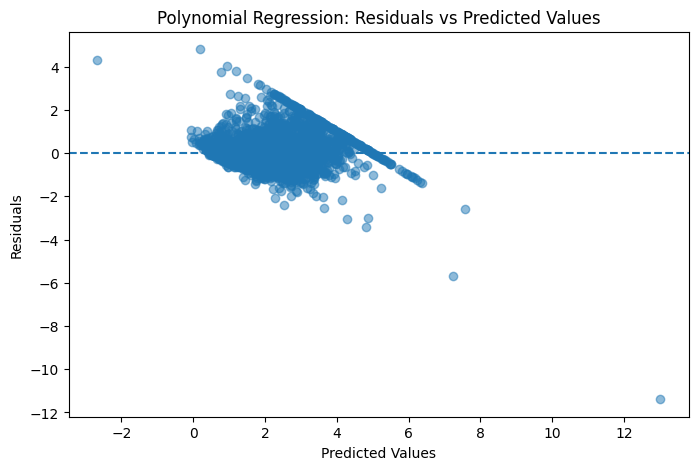

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(polynomial_predictions, polynomial_residuals, alpha=0.5)

plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Polynomial Regression: Residuals vs Predicted Values")

plt.show()

### Observation

- The residuals are distributed around the zero reference line, with both positive and negative values.
- Most residuals are concentrated near zero, indicating that the majority of predictions have relatively small errors.
- The residual spread becomes more noticeable at higher predicted values, suggesting some variation in prediction errors.
- A few observations have relatively large positive or negative residuals, indicating the presence of potential outliers.
- The plot also shows a slight pattern in the residual spread rather than a perfectly random distribution.
- Overall, the model performs reasonably well for most observations, although some larger errors and non-random patterns are present.

### Step 8.8 — Residual Distribution

A histogram of the residuals is created to examine the distribution of the Polynomial Regression model's prediction errors.

The distribution helps determine whether the residuals are approximately centered around zero and whether there are unusually large errors or skewness in the residuals.

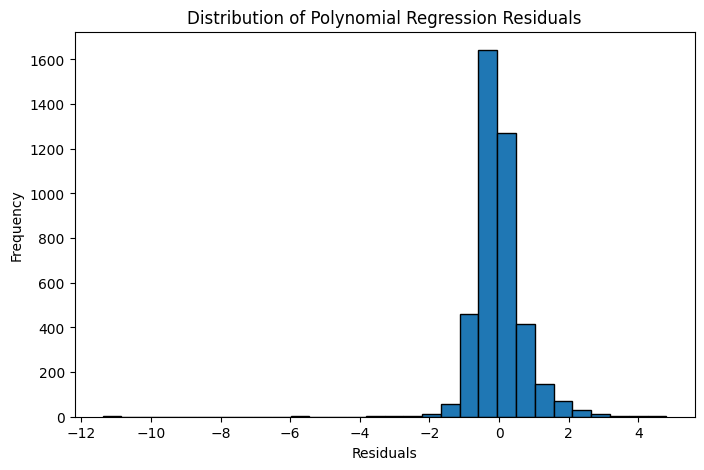

In [68]:
plt.figure(figsize=(8, 5))

plt.hist(polynomial_residuals, bins=30, edgecolor='black')

plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Distribution of Polynomial Regression Residuals")

plt.show()

### Observation

- The histogram shows that most residuals are concentrated close to zero.
- The residuals contain both negative and positive values, indicating that the model makes both over-predictions and under-predictions.
- The distribution is slightly right-skewed, with a longer tail toward positive residual values.
- A small number of extreme residuals can also be observed on both sides, indicating some observations with relatively large prediction errors.
- Overall, the residuals are reasonably centered around zero, suggesting that the Polynomial Regression model provides good predictions for most observations, although some larger errors remain.

### Step 8.9 — Actual vs Predicted Values

An Actual vs Predicted plot is created to visually evaluate how closely the Polynomial Regression predictions match the actual target values.

A reference line representing perfect predictions is added to the plot. Points closer to this line indicate more accurate predictions, while points farther away represent larger prediction errors.

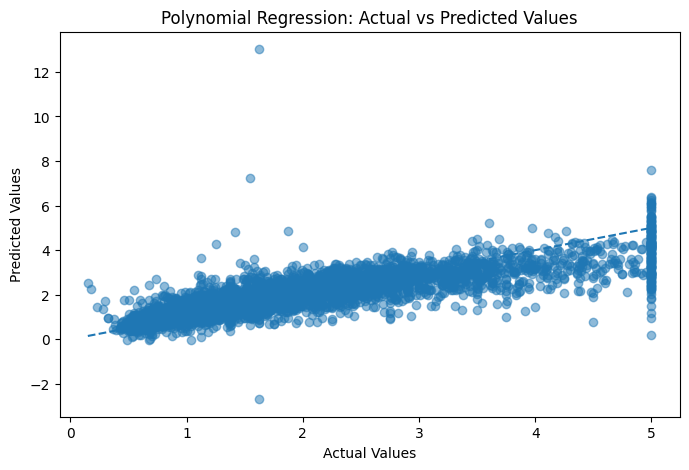

In [69]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, polynomial_predictions, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Polynomial Regression: Actual vs Predicted Values")

plt.show()

### Observation

- The plot shows an overall positive relationship between the actual and predicted values.
- Many predictions follow the general upward trend, indicating that the model is able to capture a substantial part of the relationship in the data.
- However, the points are not perfectly aligned with the reference line, showing that prediction errors are still present.
- The spread of predictions becomes wider for some higher actual values, indicating greater variation in prediction accuracy for certain observations.
- A few noticeable outliers are present, where the predicted values differ substantially from the actual values.
- Overall, the Polynomial Regression model provides reasonably good predictions, which is consistent with its R² score of approximately 0.65, but there is still room for improvement.

### Step 8.10 — Model Performance Comparison

The performance of all regression models developed during this task is compared using MAE, RMSE, and R² score.

This comparison helps identify which model provides the best overall performance on the test dataset. Lower MAE and RMSE values indicate lower prediction errors, while a higher R² score indicates that the model explains more variance in the target variable.

In [70]:
import pandas as pd

model_comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Linear Regression",
        "Ridge Regression",
        "Tuned Ridge Regression",
        "Tuned ElasticNet",
        "Polynomial Regression"
    ],
    "MAE": [
        0.906068549,
        0.533200130,
        0.533193119,
        0.533137981,
        0.533111373,
        0.467000933
    ],
    "RMSE": [
        1.144856354,
        0.745581383,
        0.745556744,
        0.745342142,
        0.745083462,
        0.681396745
    ],
    "R²": [
        -0.000219087,
        0.575787706,
        0.575815743,
        0.576059903,
        0.576354119,
        0.645681973
    ]
})

model_comparison

,Model,MAE,RMSE,R²
0,Baseline,0.906069,1.144856,-0.000219
1,Linear Regression,0.533200,0.745581,0.575788
2,Ridge Regression,0.533193,0.745557,0.575816
3,Tuned Ridge Regression,0.533138,0.745342,0.576060
4,Tuned ElasticNet,0.533111,0.745083,0.576354
5,Polynomial Regression,0.467001,0.681397,0.645682


### Observation

- The Baseline model showed the weakest performance, with the highest MAE (**0.9061**) and RMSE (**1.1449**) and a negative R² score (**-0.0002**).
- Linear Regression significantly improved the results, achieving an MAE of **0.5332** and an R² score of **0.5758**.
- Ridge Regression and Tuned Ridge Regression provided small improvements over standard Linear Regression.
- Tuned ElasticNet achieved the best performance among the regularized linear models, with an MAE of **0.5331**, RMSE of **0.7451**, and R² of **0.5764**.
- Polynomial Regression achieved the best overall performance, with the lowest MAE (**0.4670**) and RMSE (**0.6814**) and the highest R² score (**0.6457**).
- Therefore, Polynomial Regression was selected as the best-performing model among all the evaluated models.

### Step 8.11 — Final Model Selection

Based on the model performance comparison, the best-performing model is selected using MAE, RMSE, and R² score.

The selected model should have lower prediction errors and a higher R² score compared to the other evaluated models.

In [71]:
best_model = model_comparison.loc[
    model_comparison["MAE"].idxmin()
]

print("Best Model:")
print(best_model)

Best Model:
Model    Polynomial Regression
MAE                   0.467001
RMSE                  0.681397
R²                    0.645682
Name: 5, dtype: object


### Observation

- The model comparison confirmed that Polynomial Regression is the best-performing model.
- It achieved the lowest MAE of **0.467001** and the lowest RMSE of **0.681397**.
- It also achieved the highest R² score of **0.645682** among all evaluated models.
- Therefore, Polynomial Regression was selected as the final model for this task.

# STEP 9 — Residual Analysis and Model Diagnostics

Residual analysis is performed on the final selected Polynomial Regression model to examine prediction errors and assess model behavior.

A residual is calculated as the difference between the actual target value and the predicted value:

Residual = Actual Value − Predicted Value

Residual analysis helps determine whether errors are randomly distributed and whether any systematic patterns remain in the model predictions.

### Step 9.1 — Calculate Residuals

Residuals are calculated by subtracting the Polynomial Regression predictions from the actual test values.

The residuals will be used for diagnostic analysis and visualization of the final model's prediction errors.

In [72]:
residuals = y_test - polynomial_predictions

print("Number of residuals:", len(residuals))
print("Mean residual:", residuals.mean())
print("Residual standard deviation:", residuals.std())

Number of residuals: 4128
Mean residual: -0.003467522287325531
Residual standard deviation: 0.6814704693557421


### Observation

A total of **4,128 residuals** were calculated, matching the number of observations in the test dataset.

The mean residual was **-0.0035**, which is very close to zero. This suggests that the Polynomial Regression model does not show a strong overall tendency to systematically overpredict or underpredict house values.

The residual standard deviation was **0.6815**, indicating the overall spread of prediction errors around the mean residual.

These residuals will now be examined further using summary statistics and visual diagnostics.

### Step 9.2 — Residual Summary Statistics

Summary statistics are calculated to examine the distribution and spread of the residuals produced by the final Polynomial Regression model.

The minimum, maximum, mean, median, and quartile values help identify the typical range of prediction errors and detect the presence of large residuals.

In [73]:
residual_summary = pd.Series(residuals).describe()

print(residual_summary)

count    4128.000000
mean       -0.003468
std         0.681470
min       -11.388670
25%        -0.390409
50%        -0.085258
75%         0.267455
max         4.808278
Name: MedHouseVal, dtype: float64


### Observation

The residual summary shows that the mean residual is **-0.0035**, which is very close to zero and suggests no strong overall prediction bias.

The middle 50% of residuals lie between **-0.3904** and **0.2675**, indicating that most prediction errors are relatively closer to zero.

However, the minimum residual of **-11.3887** and maximum residual of **4.8083** show the presence of some large prediction errors. In particular, the extreme negative residual suggests that the model significantly overpredicted at least one observation.

Therefore, a residual plot will be used next to visually examine whether the residuals are randomly distributed around zero and to identify any potential patterns or extreme errors.

### Step 9.3 — Residuals vs Predicted Values

A residual plot is created to visually examine the distribution of prediction errors against the predicted house values.

Ideally, residuals should be randomly scattered around the zero line. A clear pattern, curve, or uneven spread may indicate that some relationships or variations are not fully captured by the model.

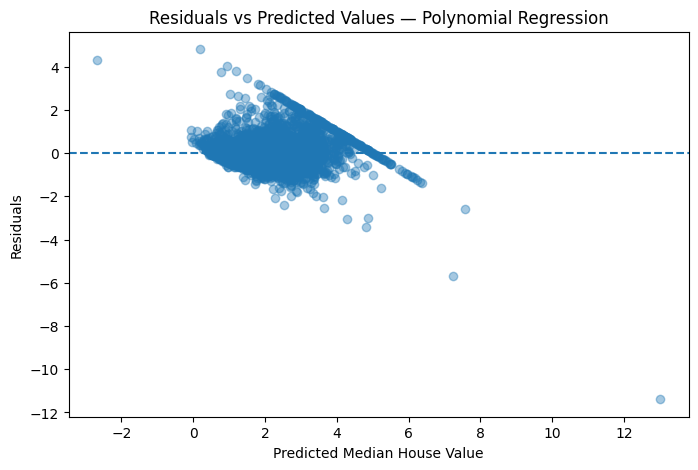

In [74]:
plt.figure(figsize=(8, 5))

plt.scatter(
    polynomial_predictions,
    residuals,
    alpha=0.4
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Median House Value")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values — Polynomial Regression")

plt.show()

### Observation

The residual plot shows that most residuals are concentrated around the zero line, which is a positive indication that the Polynomial Regression model captures a substantial part of the relationship in the data.

However, the residuals are not perfectly randomly distributed. The plot shows some variation in the spread of residuals and several extreme points, including a very large negative residual.

This indicates that although Polynomial Regression was selected as the best-performing model based on overall evaluation metrics, some observations still have large prediction errors. Therefore, the model has limitations and may not fully capture all patterns in the dataset.

### Step 9.4 — Residual Distribution

A histogram of the residuals is created to examine the distribution of prediction errors.

Ideally, residuals should be centered around zero. The distribution is examined to identify skewness, unusual patterns, and the presence of extreme prediction errors.

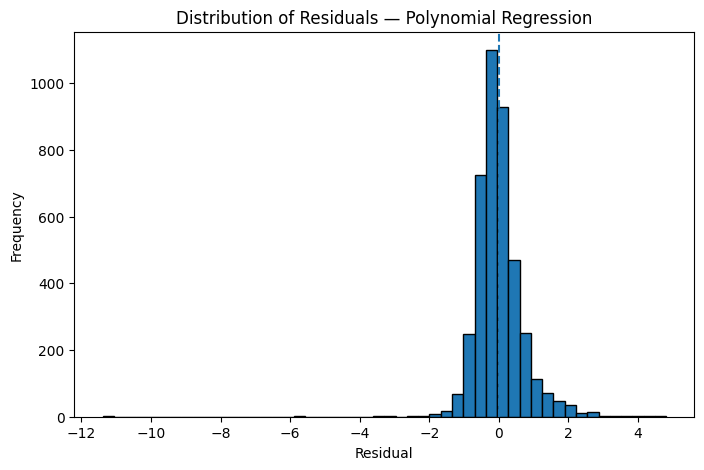

In [75]:
plt.figure(figsize=(8, 5))

plt.hist(
    residuals,
    bins=50,
    edgecolor="black"
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals — Polynomial Regression")

plt.show()

### Observation

The residual distribution is centered mainly around **zero**, with most residuals concentrated close to zero. This indicates that most predictions have relatively smaller errors.

However, the distribution shows a **long tail due to some extreme residual values**, indicating the presence of a small number of observations with large prediction errors.

Therefore, although the final Polynomial Regression model performs well overall, the residual distribution confirms that some extreme cases are not predicted accurately.

### Step 9.5 — Residual Analysis Summary

The residual analysis shows that the final Polynomial Regression model has a mean residual close to zero, indicating no strong overall prediction bias.

Most residuals are concentrated around zero, suggesting that the model produces relatively accurate predictions for many observations. However, the residual plots and summary statistics also reveal some extreme prediction errors and a non-uniform distribution of residuals.

Overall, Polynomial Regression provides the best performance among the evaluated models, but the residual analysis indicates that there is still room for improvement, particularly for unusual or extreme observations.

# STEP 10 — Prediction Interval Calculator and Business Evaluation

A prediction interval provides a range around a model prediction to reflect the uncertainty associated with individual predictions.

For this project, an approximate prediction interval is calculated using the standard deviation of the residuals from the final Polynomial Regression model.

This approach provides a simple estimate of prediction uncertainty and helps evaluate whether predictions are reliable enough for the business scenario.

### Step 10.1 — Define the Prediction Error Spread

The residual standard deviation from the final model is used as an estimate of the typical spread of prediction errors.

A larger residual spread indicates greater uncertainty in individual predictions, while a smaller spread indicates more consistent prediction errors.

In [76]:
residual_std = residuals.std()

print("Residual standard deviation:", residual_std)

Residual standard deviation: 0.6814704693557421


### Step 10.2 — Create a Prediction Interval Calculator

A reusable function is created to calculate an approximate 95% prediction interval.

The interval is calculated by adding and subtracting a margin based on the residual standard deviation from each prediction.

This provides a lower and upper estimate around each predicted house value.

In [78]:
def prediction_interval(predictions, residual_std, z_score=1.96):
    """
    Calculate an approximate prediction interval.

    Parameters:
    predictions : array-like
        Model predictions.
    residual_std : float
        Standard deviation of residuals.
    z_score : float, default=1.96
        Multiplier used for an approximate 95% interval.

    Returns:
    lower_bound : array-like
        Lower prediction interval.
    upper_bound : array-like
        Upper prediction interval.
    """

    margin = z_score * residual_std

    lower_bound = predictions - margin
    upper_bound = predictions + margin

    return lower_bound, upper_bound

### Step 10.3 — Calculate Approximate 95% Prediction Intervals

The prediction interval calculator is applied to the Polynomial Regression predictions.

For each predicted house value, a lower and upper bound are calculated to represent an approximate range of possible actual values.

In [79]:
lower_bound, upper_bound = prediction_interval(
    polynomial_predictions,
    residual_std
)

interval_results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": polynomial_predictions,
    "Lower_Bound": lower_bound,
    "Upper_Bound": upper_bound
})

interval_results.head()

,Actual,Predicted,Lower_Bound,Upper_Bound
0,0.47700,0.553997,-0.781685,1.889680
1,0.45800,1.751186,0.415504,3.086868
2,5.00001,3.492379,2.156697,4.828061
3,2.18600,2.849669,1.513986,4.185351
4,2.78000,2.762426,1.426743,4.098108


### Observation

Approximate 95% prediction intervals were successfully calculated for the Polynomial Regression predictions.

Each prediction now includes a lower and upper bound based on the residual standard deviation of the final model. This provides an estimate of prediction uncertainty rather than relying only on a single predicted value.

The intervals are relatively wide because some observations in the dataset have large residual errors. In some cases, the lower bound is negative, which highlights a limitation of this simple residual-based approximation rather than indicating a negative house value.

Therefore, the prediction intervals should be interpreted as an approximate measure of uncertainty around the model predictions.

### Step 10.4 — Evaluate the Business Accuracy Threshold

The business scenario considers predictions within **±$30,000** of the actual house value as acceptable.

Since the target variable is measured in units of **$100,000**, the business threshold is converted to:

**$30,000 ÷ $100,000 = 0.30**

The absolute prediction error of the final Polynomial Regression model is calculated for each test observation and compared with this threshold.

This evaluation determines how many individual predictions meet the business accuracy requirement.

In [80]:
business_threshold = 0.30

absolute_errors = np.abs(
    y_test - polynomial_predictions
)

acceptable_predictions = (
    absolute_errors <= business_threshold
).sum()

unacceptable_predictions = (
    absolute_errors > business_threshold
).sum()

acceptable_percentage = (
    acceptable_predictions / len(y_test)
) * 100

unacceptable_percentage = (
    unacceptable_predictions / len(y_test)
) * 100

print("Business threshold:", business_threshold)
print("Acceptable predictions:", acceptable_predictions)
print("Unacceptable predictions:", unacceptable_predictions)
print("Acceptable prediction percentage:", acceptable_percentage)
print("Unacceptable prediction percentage:", unacceptable_percentage)

Business threshold: 0.3
Acceptable predictions: 1849
Unacceptable predictions: 2279
Acceptable prediction percentage: 44.79166666666667
Unacceptable prediction percentage: 55.208333333333336


### Observation

The business accuracy evaluation shows that out of **4,128 test predictions**, **1,849 predictions (44.79%)** fall within the acceptable ±$30,000 error threshold.

However, **2,279 predictions (55.21%)** fall outside the required business accuracy range.

Therefore, although Polynomial Regression is the best-performing model among all evaluated models, it does not fully satisfy the business requirement. More than half of the predictions exceed the acceptable error threshold.

This highlights that good overall regression metrics do not necessarily guarantee that every individual business accuracy requirement is met.

### Step 10.5 — Business Evaluation Summary

The final Polynomial Regression model achieved the best overall performance among the evaluated regression models, with an MAE of **0.467001**, RMSE of **0.681397**, and R² of **0.645682**.

However, the business requirement was that predictions should be within **±$30,000** of the actual house value.

The business threshold evaluation showed that only **44.79%** of predictions met this requirement, while **55.21%** exceeded the acceptable error range.

Therefore, the final model represents a clear improvement over the baseline and other regression models, but it does not fully meet the required business accuracy standard. Further improvements, additional feature engineering, or more advanced regression approaches could be explored in future work.

# STEP 11 — Final Project Summary and Conclusion

This final section summarizes the complete regression modeling workflow, including model development, evaluation, final model selection, residual analysis, prediction uncertainty, and business impact.

### Step 11.1 — Final Model Summary

Several regression models were developed and evaluated, including a simple baseline, Linear Regression, Ridge Regression, Lasso Regression, ElasticNet Regression, and Polynomial Regression.

After comparing the models using MAE, RMSE, and R², Polynomial Regression was selected as the final model based on its overall prediction performance.

In [81]:
final_model_summary = pd.DataFrame({
    "Final Model": ["Polynomial Regression"],
    "MAE": [polynomial_mae],
    "RMSE": [polynomial_rmse],
    "R²": [polynomial_r2],
    "Average Error ($)": [polynomial_mae * 100000]
})

final_model_summary

,Final Model,MAE,RMSE,R²,Average Error ($)
0,Polynomial Regression,0.467001,0.681397,0.645682,46700.093347


### Step 11.2 — Final Results Interpretation

The final Polynomial Regression model achieved:

- **MAE:** 0.467001
- **RMSE:** 0.681397
- **R² Score:** 0.645682

Since the target variable is measured in units of $100,000, the MAE corresponds to an average prediction error of approximately **$46,700**.

The R² score of approximately **0.6457** indicates that the model explains around **64.57% of the variation** in median house values.

Compared with the baseline and other evaluated regression models, Polynomial Regression provided the strongest overall prediction performance.

### Step 11.3 — Baseline vs Final Model Improvement

The final Polynomial Regression model is compared with the simple baseline model to measure the overall improvement achieved through regression modeling and feature transformation.

In [82]:
mae_improvement = (
    (baseline_mae - polynomial_mae) / baseline_mae
) * 100

rmse_improvement = (
    (baseline_rmse - polynomial_rmse) / baseline_rmse
) * 100

r2_improvement = polynomial_r2 - baseline_r2

print(f"MAE Improvement: {mae_improvement:.2f}%")
print(f"RMSE Improvement: {rmse_improvement:.2f}%")
print(f"R² Improvement: {r2_improvement:.4f}")

MAE Improvement: 48.46%
RMSE Improvement: 40.48%
R² Improvement: 0.6459


### Observation

The final Polynomial Regression model showed a substantial improvement compared with the baseline model.

The MAE improved by **48.46%**, reducing the average prediction error significantly. The RMSE improved by **40.48%**, indicating that overall prediction errors, including larger errors, were also reduced.

The R² score increased from approximately **0** for the baseline model to **0.6457** for the final model. This means that the final model explains approximately **64.57% of the variation** in median house values.

Overall, the results demonstrate that the regression modeling and polynomial feature transformation provided a significant improvement over the simple baseline approach.

### Step 11.4 — Project Limitations

Although Polynomial Regression achieved the best performance among the evaluated models, several limitations remain.

1. The average prediction error is approximately **$46,700**, which is still above the business target of **±$30,000**.

2. Only **44.79%** of the test predictions fall within the acceptable business accuracy threshold, while **55.21%** exceed it.

3. Residual analysis identified some extreme prediction errors, indicating that the model does not perform equally well for all observations.

4. The residual distribution showed a long tail, suggesting that a small number of unusual observations have relatively large prediction errors.

5. Polynomial feature expansion increased the number of input features from **8 to 44**, which increases model complexity and may increase the risk of overfitting.

Future work could explore additional feature engineering, alternative polynomial degrees with cross-validation, and more advanced regression models to further improve prediction accuracy.

### Step 11.5 — Final Conclusion

This project developed a complete regression modeling workflow for predicting California median house values using the California Housing dataset.

The workflow included data exploration and preprocessing, baseline evaluation, Linear Regression, Ridge Regression, Lasso Regression, ElasticNet Regression, hyperparameter tuning using cross-validation, Polynomial Regression, model comparison, residual analysis, prediction interval estimation, and business threshold evaluation.

Among all evaluated models, **Polynomial Regression** was selected as the final model. It achieved an MAE of **0.467001**, RMSE of **0.681397**, and R² score of **0.645682**.

Compared with the baseline model, the final model improved MAE by **48.46%** and RMSE by **40.48%**. The final model explains approximately **64.57%** of the variation in median house values.

Despite being the best-performing model, the business evaluation showed that the model does not fully meet the required ±$30,000 prediction accuracy target. Only **44.79%** of predictions fell within the acceptable threshold.

Overall, the project successfully demonstrated an end-to-end and reproducible regression modeling workflow. The results also highlighted the importance of comparing multiple models, performing residual diagnostics, evaluating prediction uncertainty, and assessing machine learning performance against real business requirements.

## 11.6 Modular Source Code

To make the project more reusable and production-oriented, the regression workflow was divided into separate Python modules inside the `src` directory. This keeps model training, prediction, preprocessing, and evaluation functions organized and reusable.

### 11.6.1 Regression Helper Functions

The `regression_helpers.py` module contains reusable functions for calculating MAE, RMSE, R², residuals, and approximate prediction intervals.

In [85]:
%%writefile regression_helpers.py

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def evaluate_model(y_true, y_pred):
    """
    Calculate MAE, RMSE, and R² for a regression model.
    """

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    }


def calculate_residuals(y_true, y_pred):
    """
    Calculate residuals as Actual - Predicted.
    """

    return np.array(y_true) - np.array(y_pred)


def prediction_interval(predictions, residual_std, z_score=1.96):
    """
    Calculate an approximate prediction interval.
    """

    margin = z_score * residual_std

    lower_bound = predictions - margin
    upper_bound = predictions + margin

    return lower_bound, upper_bound


print("regression_helpers.py created successfully.")

Overwriting regression_helpers.py


### 11.6.2 Model Utilities

The `model_utils.py` module provides reusable functions for creating different regression models, including Linear Regression, Ridge, Lasso, ElasticNet, and Polynomial Regression.

In [86]:
%%writefile model_utils.py

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures


def create_linear_model():
    """Create a Linear Regression model."""
    return LinearRegression()


def create_ridge_model(alpha=1.0):
    """Create a Ridge Regression model with scaling."""
    return Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=alpha))
    ])


def create_lasso_model(alpha=0.01):
    """Create a Lasso Regression model with scaling."""
    return Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", Lasso(alpha=alpha))
    ])


def create_elasticnet_model(alpha=0.01, l1_ratio=0.5):
    """Create an ElasticNet Regression model with scaling."""
    return Pipeline([
        ("scaler", StandardScaler()),
        ("elasticnet", ElasticNet(alpha=alpha, l1_ratio=l1_ratio))
    ])


def create_polynomial_model(degree=2):
    """Create a Polynomial Regression model with scaling."""
    return Pipeline([
        ("polynomial", PolynomialFeatures(degree=degree, include_bias=False)),
        ("scaler", StandardScaler()),
        ("linear", LinearRegression())
    ])


print("model_utils.py created successfully.")

Writing model_utils.py


### 11.6.3 Model Training Functions

The `train_models.py` module separates model training from the main notebook and provides reusable functions for training the regression models.

In [87]:
%%writefile train_models.py

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures


def train_linear_regression(X_train, y_train):
    """Train a Linear Regression model."""
    model = LinearRegression()
    model.fit(X_train, y_train)
    return model


def train_ridge_regression(X_train, y_train, alpha=1.0):
    """Train a Ridge Regression model."""
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=alpha))
    ])
    model.fit(X_train, y_train)
    return model


def train_lasso_regression(X_train, y_train, alpha=0.01):
    """Train a Lasso Regression model."""
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", Lasso(alpha=alpha))
    ])
    model.fit(X_train, y_train)
    return model


def train_elasticnet_regression(X_train, y_train, alpha=0.01, l1_ratio=0.5):
    """Train an ElasticNet Regression model."""
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("elasticnet", ElasticNet(alpha=alpha, l1_ratio=l1_ratio))
    ])
    model.fit(X_train, y_train)
    return model


def train_polynomial_regression(X_train, y_train, degree=2):
    """Train a Polynomial Regression model."""
    model = Pipeline([
        ("polynomial", PolynomialFeatures(degree=degree, include_bias=False)),
        ("scaler", StandardScaler()),
        ("linear", LinearRegression())
    ])
    model.fit(X_train, y_train)
    return model


print("train_models.py created successfully.")

Writing train_models.py


### 11.6.4 Prediction Module

The `predict.py` module provides reusable functions for generating predictions from trained regression models and calculating prediction errors.

In [88]:

%%writefile predict.py

import numpy as np


def generate_predictions(model, X):
    """
    Generate predictions using a trained regression model.
    """
    predictions = model.predict(X)
    return np.asarray(predictions)


def calculate_prediction_error(y_true, y_pred):
    """
    Calculate prediction errors as Actual - Predicted.
    """
    return np.asarray(y_true) - np.asarray(y_pred)


print("predict.py created successfully.")


Writing predict.py


### 11.6.5 Preprocessing Module

The `preprocessing.py` module contains reusable preprocessing functions, including train-test splitting and missing-value checking.

In [89]:
%%writefile preprocessing.py

import numpy as np
from sklearn.model_selection import train_test_split


def split_data(X, y, test_size=0.2, random_state=42):
    """
    Split features and target into training and testing sets.
    """
    return train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state
    )


def check_missing_values(X):
    """
    Check the total number of missing values in the dataset.
    """
    return np.sum(np.isnan(X))


print("preprocessing.py created successfully.")

Writing preprocessing.py


### 11.6.6 Evaluation Module

The `evaluate.py` module provides reusable functions for evaluating regression predictions using MAE, RMSE, and R².

In [90]:
%%writefile evaluate.py

from regression_helpers import evaluate_model, calculate_residuals


def evaluate_predictions(y_true, y_pred):
    """
    Evaluate predictions using MAE, RMSE, and R².
    """
    metrics = evaluate_model(y_true, y_pred)
    return metrics


def get_residuals(y_true, y_pred):
    """
    Calculate residuals for a regression model.
    """
    return calculate_residuals(y_true, y_pred)


def print_evaluation_results(model_name, y_true, y_pred):
    """
    Print regression evaluation results.
    """
    metrics = evaluate_model(y_true, y_pred)

    print(f"Model: {model_name}")
    print(f"MAE: {metrics['MAE']:.6f}")
    print(f"RMSE: {metrics['RMSE']:.6f}")
    print(f"R²: {metrics['R²']:.6f}")

    return metrics


print("evaluate.py created successfully.")

Writing evaluate.py


### 11.6.7 Source Code Integration Test

The modular source-code functions were tested with the existing training and testing data. The Linear Regression model was trained, predictions were generated, and the results were evaluated successfully using the reusable source functions.

In [91]:
import sys
import os

sys.path.append(os.getcwd())

from regression_helpers import evaluate_model, calculate_residuals, prediction_interval
from model_utils import (
    create_linear_model,
    create_ridge_model,
    create_lasso_model,
    create_elasticnet_model,
    create_polynomial_model
)
from train_models import (
    train_linear_regression,
    train_ridge_regression,
    train_lasso_regression,
    train_elasticnet_regression,
    train_polynomial_regression
)
from predict import generate_predictions, calculate_prediction_error
from preprocessing import split_data
from evaluate import evaluate_predictions, get_residuals

print("All src modules imported successfully.")

regression_helpers.py created successfully.
model_utils.py created successfully.
train_models.py created successfully.
predict.py created successfully.
preprocessing.py created successfully.
evaluate.py created successfully.
All src modules imported successfully.


### 11.6.8 Source Code Integration Test

The modular source-code functions were tested with the existing California Housing training and testing data. The Linear Regression model was trained using the reusable source functions, predictions were generated, and MAE, RMSE, and R² were successfully calculated.

In [92]:
# Test src model training and evaluation

src_linear_model = train_linear_regression(X_train, y_train)

src_predictions = generate_predictions(src_linear_model, X_test)

src_metrics = evaluate_predictions(y_test, src_predictions)

print("SRC Linear Regression Results")
print("-----------------------------")
print("MAE:", src_metrics["MAE"])
print("RMSE:", src_metrics["RMSE"])
print("R²:", src_metrics["R²"])

SRC Linear Regression Results
-----------------------------
MAE: 0.5332001304956553
RMSE: 0.7455813830127764
R²: 0.5757877060324508


### 11.6.9 Source Directory Verification

The project directory was checked to verify that all reusable Python modules were created successfully and were available for the final source-code organization.

In [93]:
import os

print("Files in src folder:")
print(os.listdir())

Files in src folder:
['.config', 'model_utils.py', 'evaluate.py', 'regression_helpers.py', 'preprocessing.py', '__pycache__', 'predict.py', 'train_models.py', 'sample_data']


### 11.6.9 Final Source Organization

All reusable Python modules were organized into the `src` directory to maintain a clean, modular, and production-oriented project structure.

In [94]:
import os
import shutil

os.makedirs("src", exist_ok=True)

src_files = [
    "regression_helpers.py",
    "model_utils.py",
    "train_models.py",
    "predict.py",
    "preprocessing.py",
    "evaluate.py"
]

for file in src_files:
    if os.path.exists(file):
        shutil.move(file, os.path.join("src", file))

print("All source files moved to src/ successfully.")
print("Files in src:", os.listdir("src"))

All source files moved to src/ successfully.
Files in src: ['model_utils.py', 'evaluate.py', 'regression_helpers.py', 'preprocessing.py', 'predict.py', 'train_models.py']


### 11.6.10 Final Source Verification

The final source directory was verified to ensure that all reusable regression modules were successfully organized inside the `src` directory.

In [95]:
import os

print("Final src directory contents:")
for file in os.listdir("src"):
    print("-", file)

Final src directory contents:
- model_utils.py
- evaluate.py
- regression_helpers.py
- preprocessing.py
- predict.py
- train_models.py
